# Amazon India E-Commerce Sales Analysis
**Dataset:** Amazon India Sales Report (2022) — 128,975 transacciones  
**Objetivo:** Identificar patrones de ventas, drivers de cancelaciones y segmentos de productos para apoyar decisiones comerciales.

---
## Tabla de contenidos
1. [Carga y limpieza de datos](#1)
2. [Análisis Exploratorio (EDA)](#2)
3. [Análisis SQL con DuckDB](#3)
4. [Modelo de Clasificación — Predicción de Cancelaciones](#4)
5. [Clustering — Segmentación de Productos](#5)
6. [Conclusiones de Negocio](#6)


## 1. Carga y Limpieza de Datos <a id='1'></a>

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

import os
os.makedirs('outputs', exist_ok=True)

In [100]:
# Cargar dataset principal
df = pd.read_csv('/home/user/GIT_DATA_ANALYSIS/data/Amazon_Sale_Report.csv', encoding='latin1', low_memory=False)
intl = pd.read_csv('/home/user/GIT_DATA_ANALYSIS/data/International_sale_Report.csv', encoding='latin1')
inventory = pd.read_csv('/home/user/GIT_DATA_ANALYSIS/data/Sale_Report.csv', encoding='latin1')

print(f"Amazon Sales:         {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"International Sales:  {intl.shape[0]:,} filas × {intl.shape[1]} columnas")
print(f"Inventory Report:     {inventory.shape[0]:,} filas × {inventory.shape[1]} columnas")


Amazon Sales:         128,975 filas × 24 columnas
International Sales:  37,432 filas × 10 columnas
Inventory Report:     9,271 filas × 7 columnas


In [101]:
df.head(3)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [103]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [104]:
#intl.head(3)

In [105]:
#inventory.head(3)

### 1.1 Diagnóstico de calidad
Antes de analizar, identificamos columnas con valores nulos y columnas irrelevantes.


In [106]:
# Resumen de nulos
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
print("Columnas con valores nulos (%):")
print(null_pct.to_string())


Columnas con valores nulos (%):
fulfilled-by      69.5
promotion-ids     38.1
Unnamed: 22       38.0
currency           6.0
Amount             6.0
Courier Status     5.3


In [107]:
# ── Limpieza ──────────────────────────────────────────────────────────────────

# 1. Eliminar columnas sin valor analítico
drop_cols = ['Unnamed: 22', 'promotion-ids', 'fulfilled-by', 'currency',
             'ASIN', 'ship-postal-code', 'index']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# 2. Limpiar nombres de columnas PRIMERO
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# 3. Parsear fechas (ahora ya es 'date' minúscula)
df['date'] = pd.to_datetime(df['date'], format='%m-%d-%y', errors='coerce')
df['month']      = df['date'].dt.month
df['monthname']  = df['date'].dt.strftime('%b-%Y')
df['week']       = df['date'].dt.isocalendar().week.astype(int)

# 4. Estandarizar texto
df['status']     = df['status'].str.strip()
df['category']   = df['category'].str.strip()
df['ship_state'] = df['ship_state'].str.strip().str.title()

# 5. Eliminar filas sin monto
df.dropna(subset=['amount'], inplace=True)

# 6. Columna target para ML
df['cancelled'] = df['status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

print(f"   Limpieza completa. Filas restantes: {len(df):,}")
print(f"   Cancelaciones: {df['cancelled'].sum():,} ({df['cancelled'].mean()*100:.1f}%)")


   Limpieza completa. Filas restantes: 121,180
   Cancelaciones: 10,766 (8.9%)


In [108]:
df.info()

<class 'pandas.DataFrame'>
Index: 121180 entries, 0 to 128974
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            121180 non-null  str           
 1   date                121180 non-null  datetime64[us]
 2   status              121180 non-null  str           
 3   fulfilment          121180 non-null  str           
 4   sales_channel       121180 non-null  str           
 5   ship_service_level  121180 non-null  str           
 6   style               121180 non-null  str           
 7   sku                 121180 non-null  str           
 8   category            121180 non-null  str           
 9   size                121180 non-null  str           
 10  courier_status      116044 non-null  str           
 11  qty                 121180 non-null  int64         
 12  amount              121180 non-null  float64       
 13  ship_city           121149 non-null  str     

In [109]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col:30s} → {df[col].nunique():4d} categorías únicas")

order_id                       → 113030 categorías únicas
status                         →   12 categorías únicas
fulfilment                     →    2 categorías únicas
sales_channel                  →    1 categorías únicas
ship_service_level             →    2 categorías únicas
style                          → 1373 categorías únicas
sku                            → 7157 categorías únicas
category                       →    9 categorías únicas
size                           →   11 categorías únicas
courier_status                 →    2 categorías únicas
ship_city                      → 8704 categorías únicas
ship_state                     →   46 categorías únicas
ship_country                   →    1 categorías únicas
monthname                      →    4 categorías únicas


In [110]:
for col in ['category', 'status', 'size', 'fulfilment', 'ship_service_level']:
    print(f"\n── {col} ──")
    print(df[col].value_counts())


── category ──
category
Set              47042
kurta            46717
Western Dress    14704
Top              10165
Ethnic Dress      1093
Blouse             881
Bottom             420
Saree              155
Dupatta              3
Name: count, dtype: int64

── status ──
status
Shipped                          77596
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

── size ──
size
M       21292
L       20800
XL      19726
XXL     17066
S       15953
3XL     14052
XS      10296
6XL       705
5XL       526
4XL       408
Free      356
Name: count, dtype: int64

── fulfilment ──
fulfilment
A

In [111]:
print(df['courier_status'].value_counts())

courier_status
Shipped      109487
Unshipped      6557
Name: count, dtype: int64


In [112]:
df['courier_status'] = df['courier_status'].apply(lambda x: 'Cancelled' if pd.isnull(x) else x)
#df[['courier_status']].info()        0   courier_status  121180 non-null  str  
print(f"{df['courier_status'].nunique():4d} categorías únicas")

   3 categorías únicas


In [113]:
print(df['status'].unique())

<StringArray>
[                    'Cancelled',  'Shipped - Delivered to Buyer',
                       'Shipped',  'Shipped - Returned to Seller',
   'Shipped - Rejected by Buyer',     'Shipped - Lost in Transit',
    'Shipped - Out for Delivery', 'Shipped - Returning to Seller',
           'Shipped - Picked Up',                       'Pending',
 'Pending - Waiting for Pick Up',             'Shipped - Damaged']
Length: 12, dtype: str


In [114]:
# ── Integrar devoluciones como feature adicional ───────────────────────────────

# Clasificar estados en categorías de riesgo
def clasificar_status(s):
    if s == 'Cancelled':
        return 'cancelada'
    elif s in ['Shipped - Returned to Seller', 'Shipped - Rejected by Buyer', 
               'Shipped - Returning to Seller']:
        return 'devolucion'
    elif s in ['Shipped - Lost in Transit', 'Shipped - Damaged']:
        return 'perdida_dano'
    elif s in ['Pending', 'Pending - Waiting for Pick Up']:
        return 'pendiente'
    else:
        return 'completada'

df['status_categoria'] = df['status'].apply(clasificar_status)
df['devolucion'] = (df['status_categoria'] == 'devolucion').astype(int)
df['orden_problematica'] = (df['status_categoria'].isin(['cancelada', 'devolucion', 'perdida_daño'])).astype(int)

print("Distribución de categorías de status:")
print(df['status_categoria'].value_counts())
print(f"\nTasa de devolución: {df['devolucion'].mean()*100:.2f}%")
print(f"Tasa de órdenes problemáticas: {df['orden_problematica'].mean()*100:.2f}%")

Distribución de categorías de status:
status_categoria
completada      107365
cancelada        10766
devolucion        2106
pendiente          937
perdida_dano         6
Name: count, dtype: int64

Tasa de devolución: 1.74%
Tasa de órdenes problemáticas: 10.62%


## 2. Análisis Exploratorio de Datos (EDA) <a id='2'></a>

### 2.1 Tendencia de ventas en el tiempo

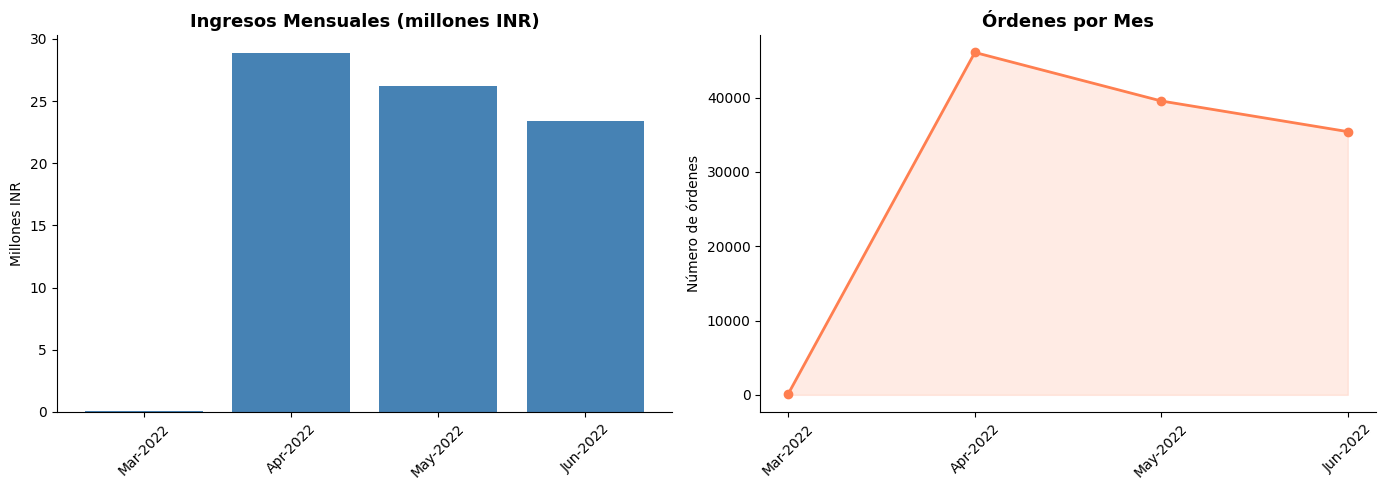

In [115]:
monthly = df.groupby('monthname').agg(
    revenue=('amount', 'sum'),
    orders=('order_id', 'count')
).reset_index()

# Ordenar cronológicamente
month_order = df.groupby('monthname')['date'].min().sort_values().index
monthly = monthly.set_index('monthname').loc[month_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly['monthname'], monthly['revenue'] / 1e6, color='steelblue')
axes[0].set_title('Ingresos Mensuales (millones INR)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Millones INR')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['monthname'], monthly['orders'], marker='o', color='coral', linewidth=2)
axes[1].fill_between(range(len(monthly)), monthly['orders'], alpha=0.15, color='coral')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['monthname'], rotation=45)
axes[1].set_title('Órdenes por Mes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de órdenes')

plt.tight_layout()
plt.savefig('outputs/01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
#El pico de ventas se concentra en abril 2022.


### 2.2 Ventas por categoría de producto

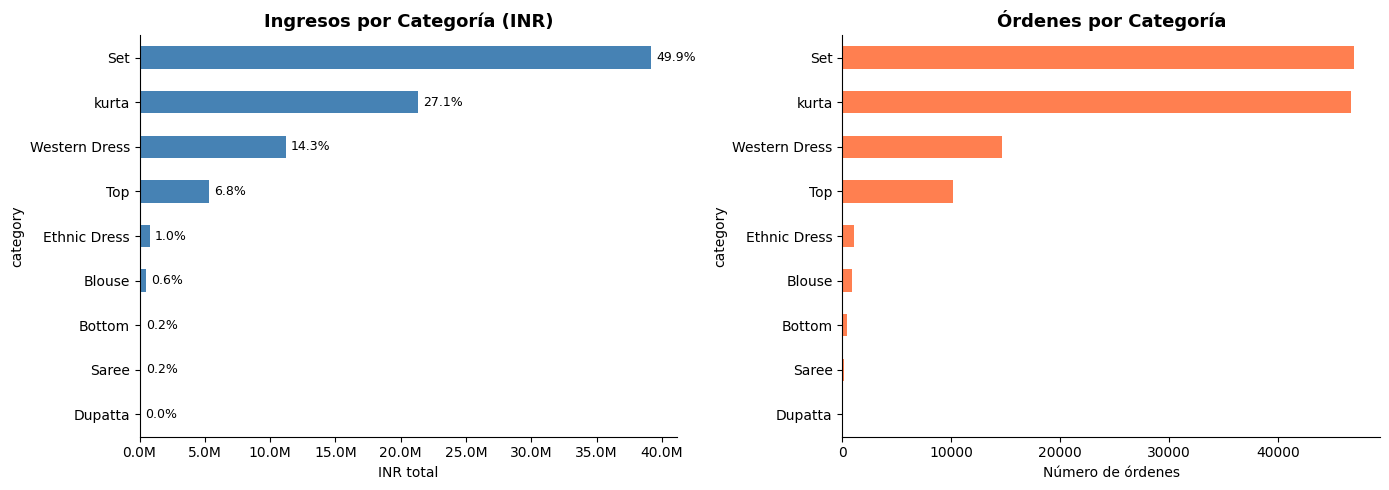

In [116]:
cat_revenue = df.groupby('category')['amount'].sum().sort_values(ascending=True)
cat_orders  = df.groupby('category')['order_id'].count().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_revenue.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Ingresos por Categoría (INR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('INR total')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Anotar porcentaje del total en cada barra
for bar, val in zip(axes[0].patches, cat_revenue.values):
    pct = val / cat_revenue.sum() * 100
    axes[0].text(bar.get_width() + cat_revenue.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{pct:.1f}%', va='center', fontsize=9)
    
cat_orders.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Órdenes por Categoría', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de órdenes')

plt.tight_layout()
plt.savefig('outputs/02_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: 'Set' y 'Kurta' representan el 77% de las ventas totales.


### 2.3 Distribución geográfica — Top 15 estados

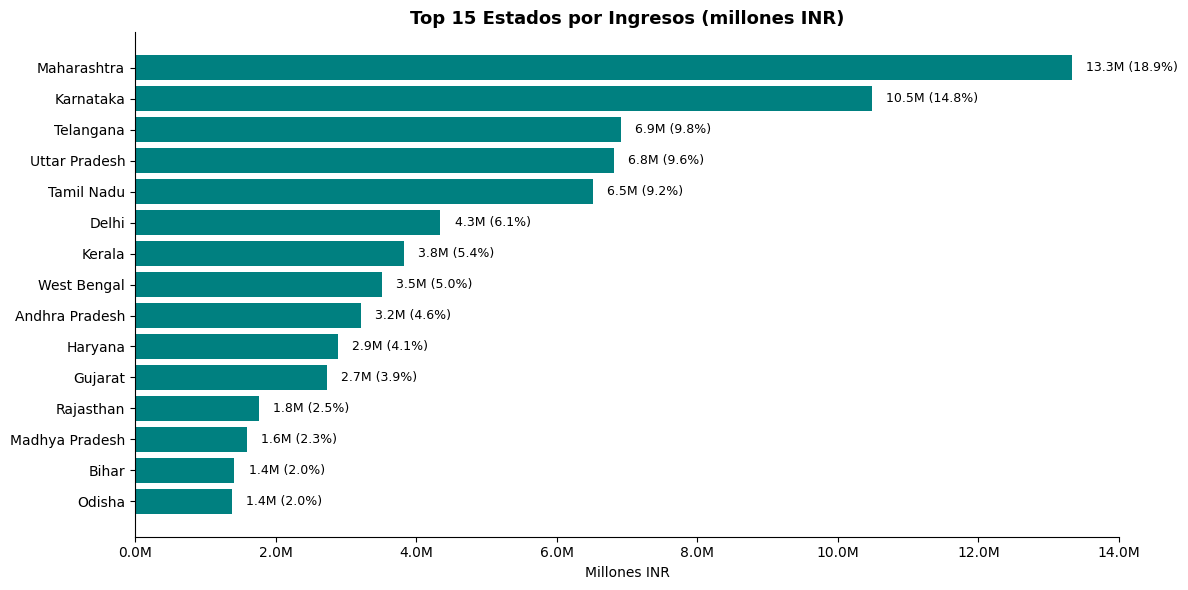

In [117]:
state_revenue = (df.groupby('ship_state')['amount']
                   .sum()
                   .sort_values(ascending=False)
                   .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_revenue.index[::-1], state_revenue.values[::-1] / 1e6, color='teal')
ax.set_title('Top 15 Estados por Ingresos (millones INR)', fontsize=13, fontweight='bold')
ax.set_xlabel('Millones INR')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}M'))

for bar, val in zip(bars, state_revenue.values[::-1]):
    pct = val / state_revenue.sum() * 100
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/03_state_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: Maharashtra, Karnataka y Telangana concentran ~43.5% del ingreso total.


### 2.4 Tasa de cancelación por categoría

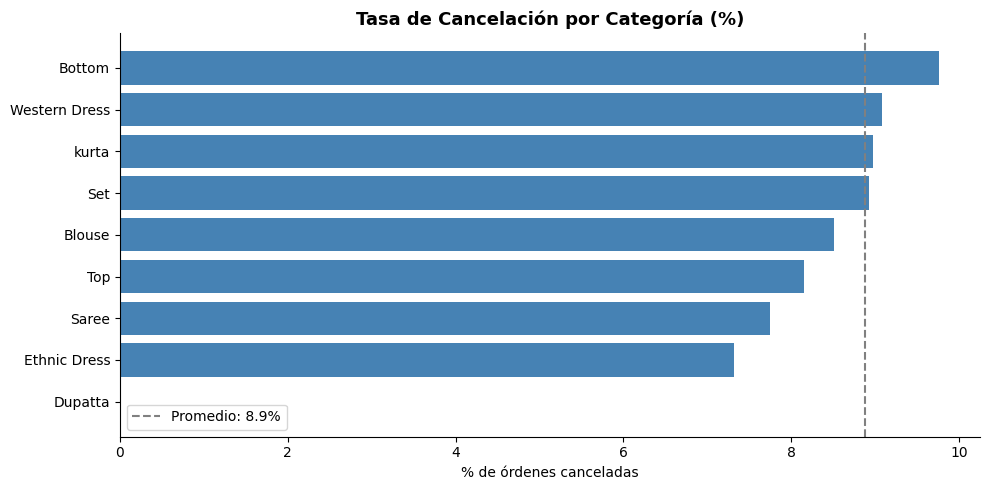

In [118]:
cancel_cat = df.groupby('category').agg(
    total=('order_id', 'count'),
    cancelled=('cancelled', 'sum')
).reset_index()
cancel_cat['cancel_rate'] = cancel_cat['cancelled'] / cancel_cat['total'] * 100
cancel_cat = cancel_cat.sort_values('cancel_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d9534f' if r > 20 else 'steelblue' for r in cancel_cat['cancel_rate']]
ax.barh(cancel_cat['category'], cancel_cat['cancel_rate'], color=colors)
ax.axvline(df['cancelled'].mean() * 100, color='gray', linestyle='--', label=f"Promedio: {df['cancelled'].mean()*100:.1f}%")
ax.set_title('Tasa de Cancelación por Categoría (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('% de órdenes canceladas')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/04_cancellation_rate.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: Las categorías con mayor tasa de cancelación superan el promedio general del 8.9%."


### 2.5 Amazon Fulfillment vs Merchant & B2B vs B2C

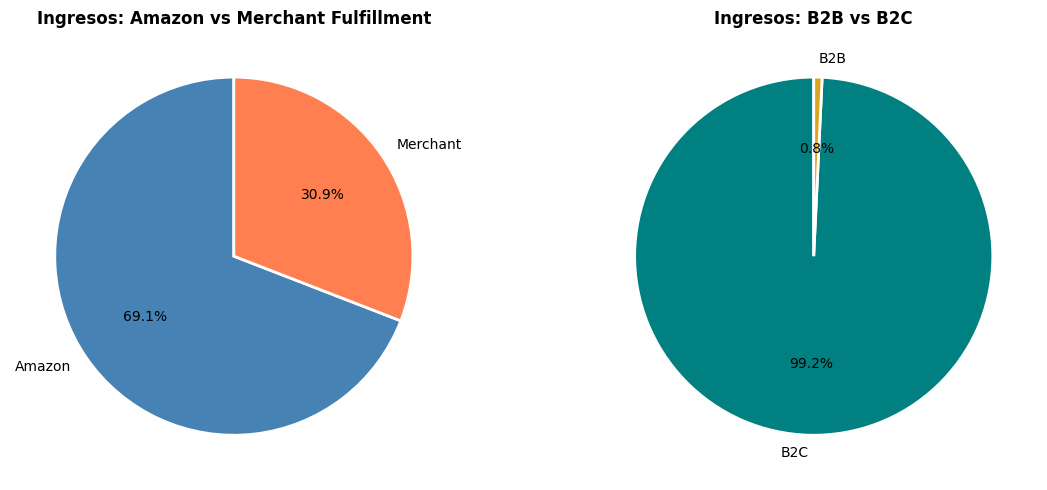

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fulfillment
df.groupby('fulfilment')['amount'].sum().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=['steelblue', 'coral'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Ingresos: Amazon vs Merchant Fulfillment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')

# B2B vs B2C
df.groupby('b2b')['amount'].sum().rename({True: 'B2B', False: 'B2C'}).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['teal', 'goldenrod'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Ingresos: B2B vs B2C', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('outputs/05_fulfillment_b2b.png', dpi=150, bbox_inches='tight')
plt.show()
#Insight: Amazon Fulfillment domina con ~69.1% del ingreso. B2B es <1% pero con tickets más altos.


### 2.6 Distribución de órdenes por categoría de status

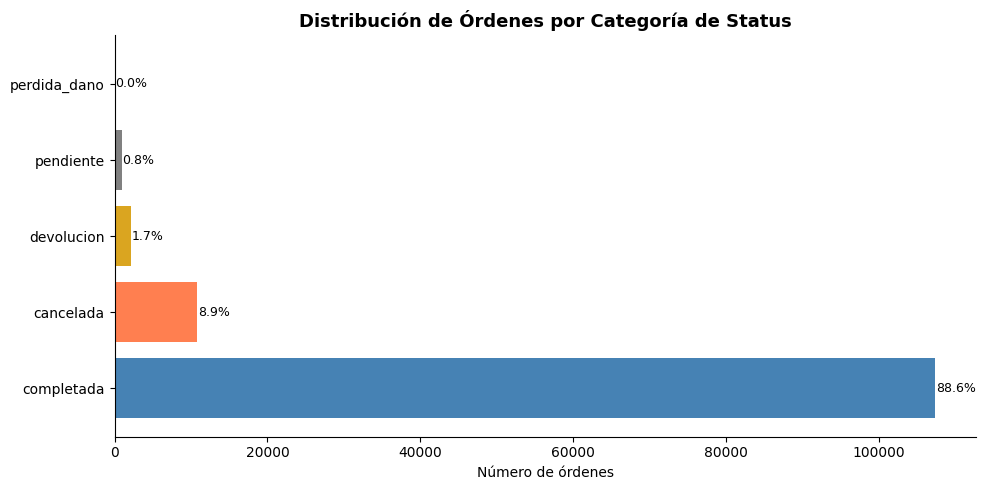

In [120]:
status_dist = df['status_categoria'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'completada': 'steelblue', 'cancelada': 'coral', 
          'devolucion': 'goldenrod', 'pendiente': 'gray', 'perdida_dano': 'darkred'}
bars = ax.barh(status_dist.index, status_dist.values, 
               color=[colors[s] for s in status_dist.index])
ax.set_title('Distribución de Órdenes por Categoría de Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de órdenes')

for bar, val in zip(bars, status_dist.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/12_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Análisis SQL con DuckDB <a id='3'></a>

Usamos DuckDB para ejecutar SQL directamente sobre los DataFrames de pandas.

In [121]:
import duckdb

con = duckdb.connect()
con.register('amazon_sales', df)
con.register('international_sales', intl)
con.register('inventory', inventory)
print("DuckDB conectado con 3 tablas registradas")


DuckDB conectado con 3 tablas registradas


### 3.1 Top 10 estados por ingreso y tasa de cancelación

In [122]:
query_1 = '''
    SELECT
        ship_state                                          AS estado,
        COUNT(*)                                            AS total_ordenes,
        ROUND(SUM(amount), 0)                              AS ingreso_total,
        ROUND(AVG(amount), 0)                              AS ticket_promedio,
        ROUND(SUM(cancelled) * 100.0 / COUNT(*), 2)       AS tasa_cancelacion_pct
    FROM amazon_sales
    WHERE ship_state IS NOT NULL
    GROUP BY ship_state
    ORDER BY ingreso_total DESC
    LIMIT 10
'''

result_1 = con.execute(query_1).df()
result_1


,estado,total_ordenes,ingreso_total,ticket_promedio,tasa_cancelacion_pct
0,Maharashtra,21073,13335534.0,633.0,8.55
1,Karnataka,16394,10481114.0,639.0,8.04
2,Telangana,10637,6916616.0,650.0,8.91
3,Uttar Pradesh,9947,6816642.0,685.0,9.23
4,Tamil Nadu,10809,6515650.0,603.0,8.62
5,Delhi,6569,4346412.0,662.0,7.84
6,Kerala,6151,3830228.0,623.0,12.10
7,West Bengal,5547,3507880.0,632.0,8.53
8,Andhra Pradesh,5055,3219832.0,637.0,10.41
9,Haryana,4188,2882093.0,688.0,8.14


### 3.2 Análisis con Window Functions — Ranking de categorías por mes

In [123]:
query_2 = '''
    WITH monthly_cat AS (
        SELECT
            monthname                                           AS mes,
            category,
            SUM(amount)                                        AS ingreso,
            RANK() OVER (PARTITION BY monthname ORDER BY SUM(amount) DESC) AS rank_mes
        FROM amazon_sales
        GROUP BY monthname, category
    )
    SELECT mes, category, ROUND(ingreso, 0) AS ingreso, rank_mes
    FROM monthly_cat
    WHERE rank_mes <= 3
    ORDER BY mes, rank_mes
'''

result_2 = con.execute(query_2).df()
result_2


,mes,category,ingreso,rank_mes
0,Apr-2022,Set,15506676.0,1
1,Apr-2022,kurta,8017145.0,2
2,Apr-2022,Western Dress,2927781.0,3
3,Jun-2022,Set,10999866.0,1
4,Jun-2022,kurta,6587568.0,2
5,Jun-2022,Western Dress,3899334.0,3
6,Mar-2022,Set,53884.0,1
7,Mar-2022,kurta,34257.0,2
8,Mar-2022,Western Dress,7653.0,3
9,May-2022,Set,12643698.0,1


### 3.3 Comparativa: ventas Amazon India vs Internacional (por categoría de tamaño)

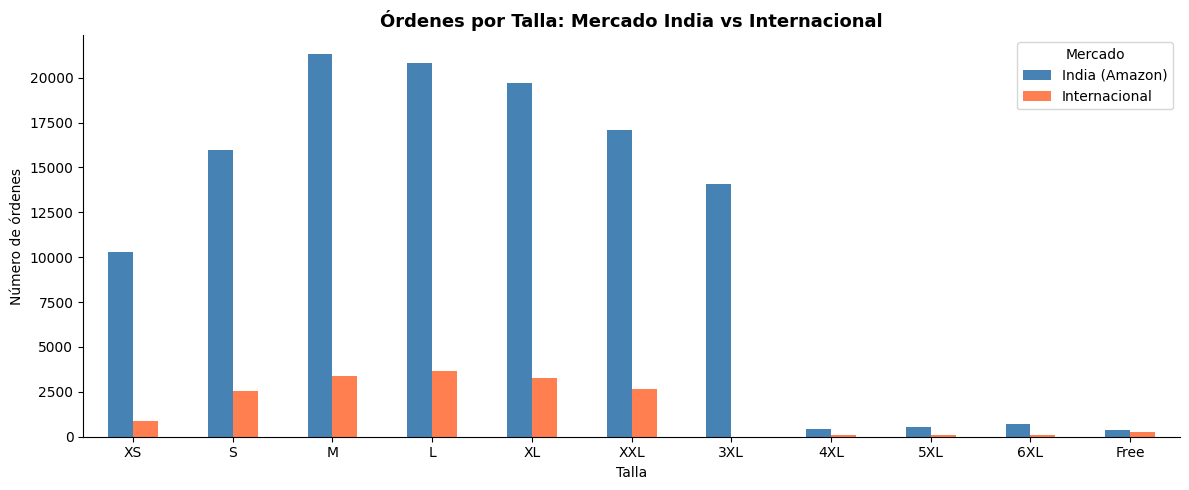

In [124]:
query_3 = '''
    SELECT
        'India (Amazon)'    AS mercado,
        size,
        COUNT(*)            AS ordenes,
        ROUND(SUM(amount), 0) AS ingreso
    FROM amazon_sales
    WHERE size IS NOT NULL
    GROUP BY size

    UNION ALL

    SELECT
        'Internacional'     AS mercado,
        "Size"              AS size,
        COUNT(*)            AS ordenes,
        ROUND(SUM(TRY_CAST("GROSS AMT" AS DOUBLE)), 0) AS ingreso
    FROM international_sales
    WHERE "Size" IS NOT NULL
    GROUP BY "Size"

    ORDER BY mercado, ordenes DESC
'''

result_3 = con.execute(query_3).df()

# Visualización
pivot = result_3.pivot_table(index='size', columns='mercado', values='ordenes', fill_value=0)
top_sizes = ['XS','S','M','L','XL','XXL','3XL','4XL','5XL','6XL','Free']
pivot = pivot.reindex([s for s in top_sizes if s in pivot.index])

pivot.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'coral'])
plt.title('Órdenes por Talla: Mercado India vs Internacional', fontsize=13, fontweight='bold')
plt.xlabel('Talla')
plt.ylabel('Número de órdenes')
plt.xticks(rotation=0)
plt.legend(title='Mercado')
plt.tight_layout()
plt.savefig('outputs/06_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# M y L dominan en ambos mercados.


## 4. Modelo de Clasificación — Predicción de Cancelaciones <a id='4'></a>

**Objetivo:** Predecir si una orden será cancelada antes de ser enviada.  
**Valor de negocio:** Permite intervenir proactivamente en órdenes de alto riesgo, reduciendo pérdidas operativas.


In [125]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# ── Feature Engineering ────────────────────────────────────────────────────────
ml_df = df[['category', 'size', 'fulfilment', 'ship_service_level',
            'b2b', 'qty', 'amount', 'month',
            'cancelled']].dropna().copy()

# Codificar variables categóricas
le = LabelEncoder()
for col in ['category', 'size', 'fulfilment', 'ship_service_level']:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

ml_df['b2b'] = ml_df['b2b'].astype(int)

X = ml_df.drop('cancelled', axis=1)
y = ml_df['cancelled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} muestras | Test: {X_test.shape[0]:,} muestras")
print(f"Balance de clases — Canceladas: {y.mean()*100:.1f}%")


Train: 96,944 muestras | Test: 24,236 muestras
Balance de clases — Canceladas: 8.9%


In [126]:
# ── Logistic Regression ────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

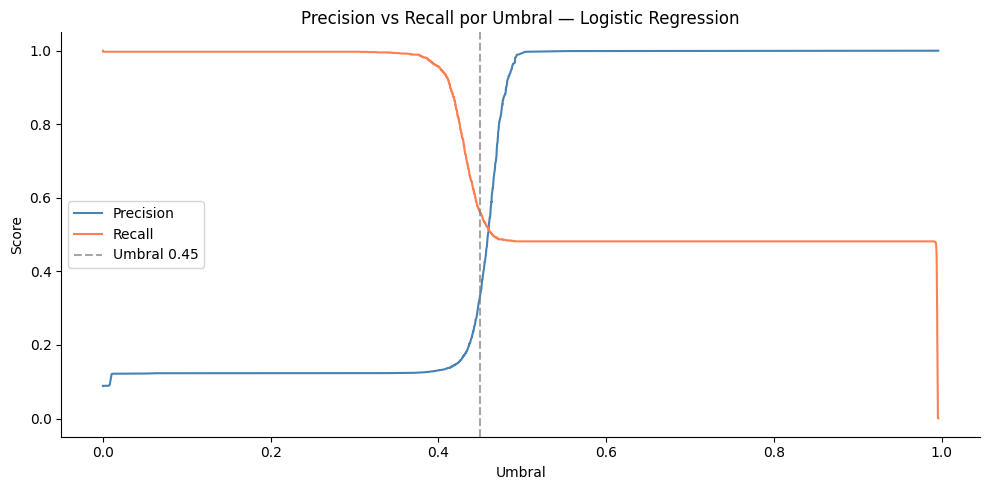

Umbral óptimo (recall >= 0.50): 0.464
Precision: 0.62 | Recall: 0.50 | F1: 0.55


In [127]:
# Curva Precision-Recall por umbral
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, lr_proba)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision_curve[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall_curve[:-1], label='Recall', color='coral')
plt.axvline(0.45, color='gray', linestyle='--', alpha=0.7, label='Umbral 0.45')
plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Precision vs Recall por Umbral — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# Asegurar tamaños consistentes
min_len = min(len(precision_curve), len(recall_curve), len(thresholds))
precision_curve = precision_curve[:min_len]
recall_curve = recall_curve[:min_len]
thresholds = thresholds[:min_len]
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)

# Umbral óptimo con recall mínimo de 0.50
mask = recall_curve >= 0.50
f1_scores_masked = f1_scores[mask]
thresholds_masked = thresholds[mask]

optimal_idx = f1_scores_masked.argmax()
print(f"Umbral óptimo (recall >= 0.50): {thresholds_masked[optimal_idx]:.3f}")
print(f"Precision: {precision_curve[mask][optimal_idx]:.2f} | Recall: {recall_curve[mask][optimal_idx]:.2f} | F1: {f1_scores_masked[optimal_idx]:.2f}")

In [128]:
# Ajustar umbral a 0.464 para mejorar recall
print("=== Logistic Regression ===")
lr_pred_adjusted = (lr_proba >= 0.464).astype(int)
print(classification_report(y_test, lr_pred_adjusted, target_names=['No cancelada', 'Cancelada']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

No cancelada       0.95      0.97      0.96     22083
   Cancelada       0.61      0.50      0.55      2153

    accuracy                           0.93     24236
   macro avg       0.78      0.73      0.76     24236
weighted avg       0.92      0.93      0.92     24236

ROC-AUC: 0.8204


In [129]:
# ── Random Forest ──────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"Mejores parámetros: {grid.best_params_}")
print(f"Mejor F1: {grid.best_score_:.3f}")

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: inv

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor F1: 0.645


In [130]:
rf_best = RandomForestClassifier(
    max_depth=5,
    min_samples_leaf=1,
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_best.fit(X_train, y_train)
rf_best_pred = rf_best.predict(X_test)
rf_best_proba = rf_best.predict_proba(X_test)[:, 1]
rf_pred_adjusted = (rf_best_proba >= 0.46).astype(int)

print("=== Random Forest ===")
print(classification_report(y_test, rf_best_pred, target_names=['No cancelada', 'Cancelada']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_best_proba):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

No cancelada       0.95      1.00      0.98     22083
   Cancelada       1.00      0.48      0.65      2153

    accuracy                           0.95     24236
   macro avg       0.98      0.74      0.81     24236
weighted avg       0.96      0.95      0.95     24236

ROC-AUC: 0.8302


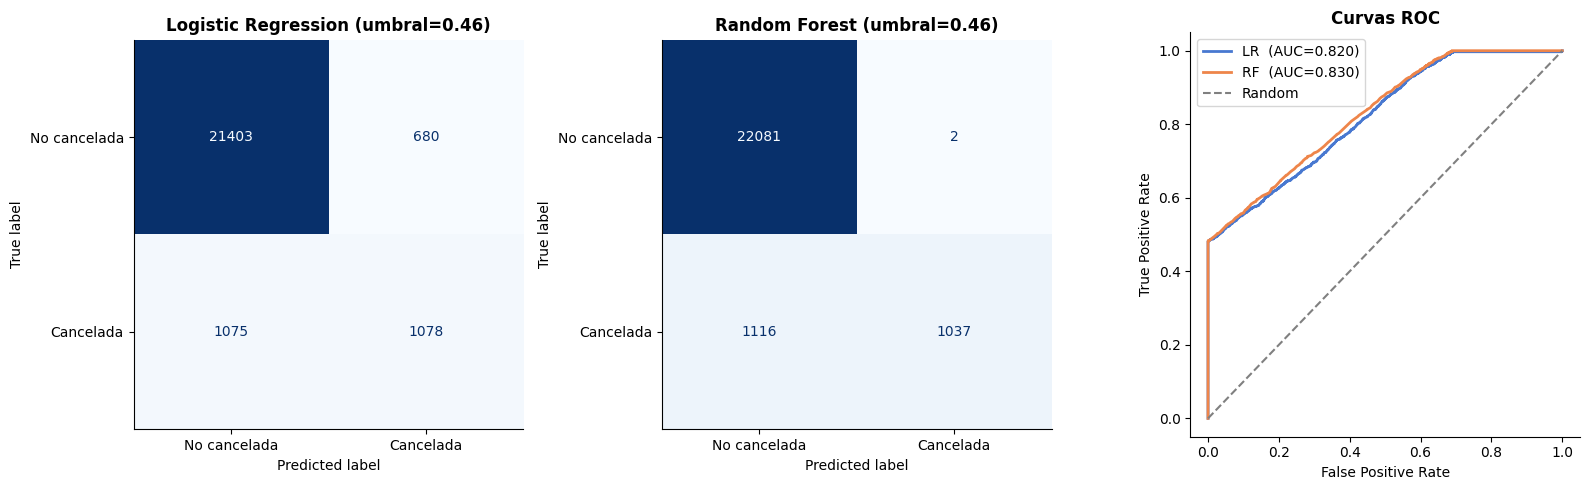

In [131]:
# ── Comparativa visual ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, pred, title in zip(axes[:2],
                            [lr_pred_adjusted, rf_pred_adjusted],
                            ['Logistic Regression (umbral=0.46)', 'Random Forest (umbral=0.46)']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No cancelada', 'Cancelada'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_best_proba)

axes[2].plot(fpr_lr, tpr_lr, label=f'LR  (AUC={roc_auc_score(y_test, lr_proba):.3f})', lw=2)
axes[2].plot(fpr_rf, tpr_rf, label=f'RF  (AUC={roc_auc_score(y_test, rf_best_proba):.3f})', lw=2)
axes[2].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[2].set_title('Curvas ROC', fontsize=12, fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


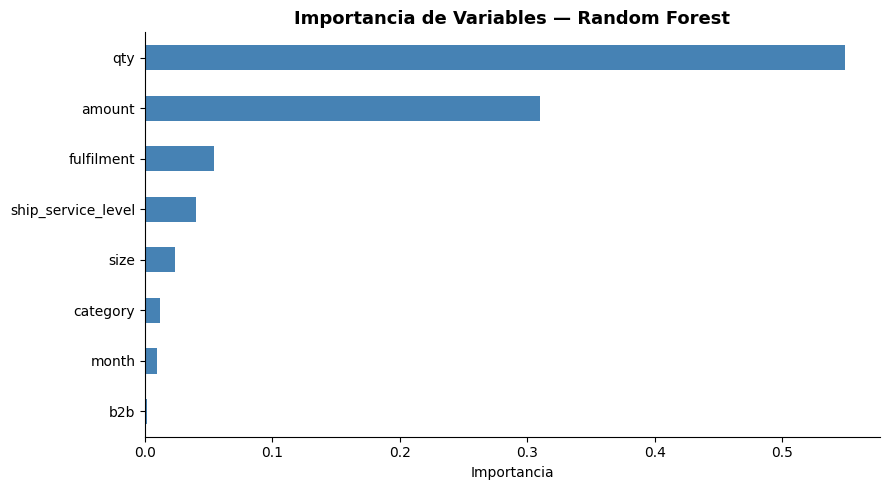

In [132]:
# ── Feature Importance (Random Forest) ────────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('outputs/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
#El monto de la orden y la cantidad son los mejores predictores de cancelación.


## 5. Clustering — Segmentación de Productos <a id='5'></a>

**Objetivo:** Identificar segmentos naturales de productos según su comportamiento de ventas.  
**Valor de negocio:** Permite diseñar estrategias diferenciadas de pricing, inventario y marketing por segmento.


In [133]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Agregamos métricas por categoría + talla
cluster_df = df.groupby(['category', 'size']).agg(
    total_orders=('order_id', 'count'),
    total_revenue=('amount', 'sum'),
    avg_ticket=('amount', 'mean'),
    cancel_rate=('cancelled', 'mean'),
    avg_qty=('qty', 'mean')
).reset_index().dropna()

features = ['total_orders', 'total_revenue', 'avg_ticket', 'cancel_rate', 'avg_qty']
X_clus = cluster_df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clus)
print(f" Datos para clustering: {X_scaled.shape[0]} combinaciones categoría×talla")


 Datos para clustering: 57 combinaciones categoría×talla


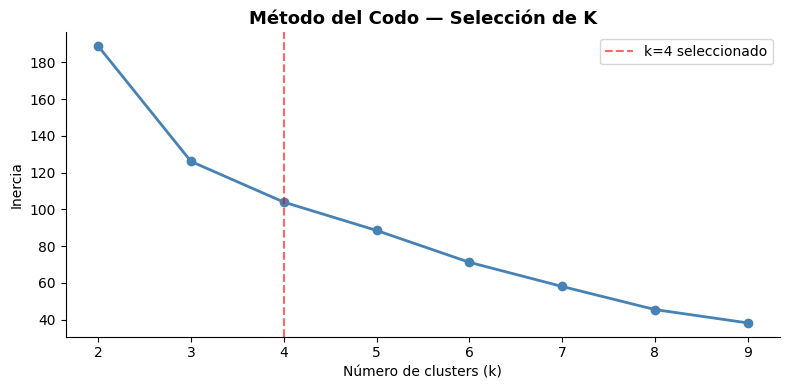

In [134]:
# ── Método del Codo (Elbow) ───────────────────────────────────────────────────
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
ax.axvline(4, color='red', linestyle='--', alpha=0.6, label='k=4 seleccionado')
ax.set_title('Método del Codo — Selección de K', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/09_elbow.png', dpi=150, bbox_inches='tight')
plt.show()


In [135]:
# ── Aplicar K-Means con k=4 ───────────────────────────────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

# Perfiles por cluster
profile = cluster_df.groupby('cluster')[features].mean().round(2)
profile.index = [f'Cluster {i}' for i in profile.index]
print("Perfil de clusters:")
print(profile.to_string())


Perfil de clusters:
           total_orders  total_revenue  avg_ticket  cancel_rate  avg_qty
Cluster 0        674.86      401312.55      621.31         0.07     0.97
Cluster 1        890.53      611512.95      543.09         0.10     0.95
Cluster 2       6864.31     4456125.91      654.39         0.09     0.96
Cluster 3         59.00       71806.44     1215.18         0.07     0.99


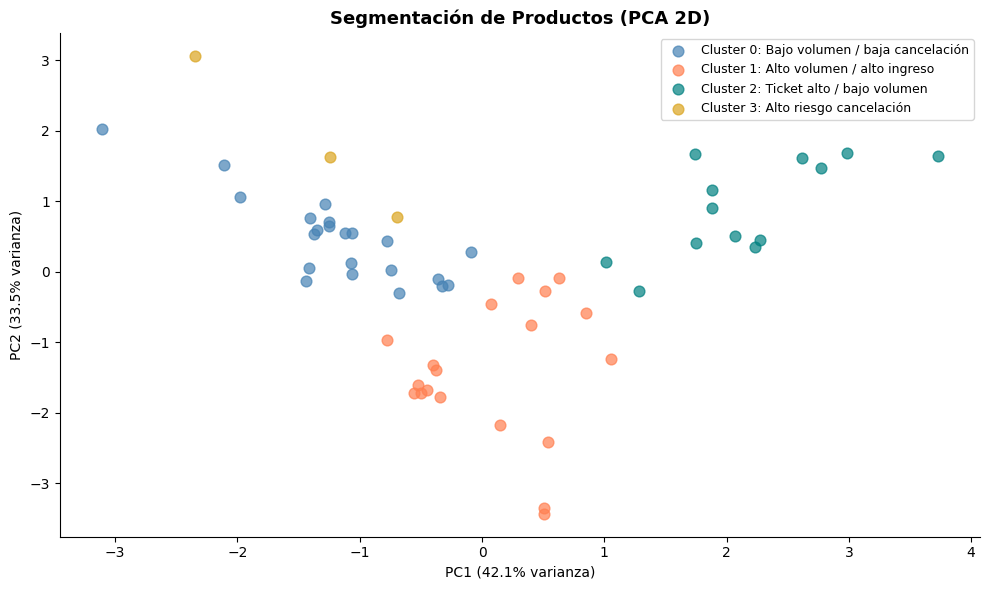

In [136]:
# ── Visualización PCA (2D) ────────────────────────────────────────────────────
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 6))
colors_clus = ['steelblue', 'coral', 'teal', 'goldenrod']
labels_clus = ['Bajo volumen / baja cancelación',
               'Alto volumen / alto ingreso',
               'Ticket alto / bajo volumen',
               'Alto riesgo cancelación']

for c in range(4):
    mask = cluster_df['cluster'] == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colors_clus[c], label=f'Cluster {c}: {labels_clus[c]}',
               alpha=0.7, s=60)

ax.set_title('Segmentación de Productos (PCA 2D)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/10_clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()


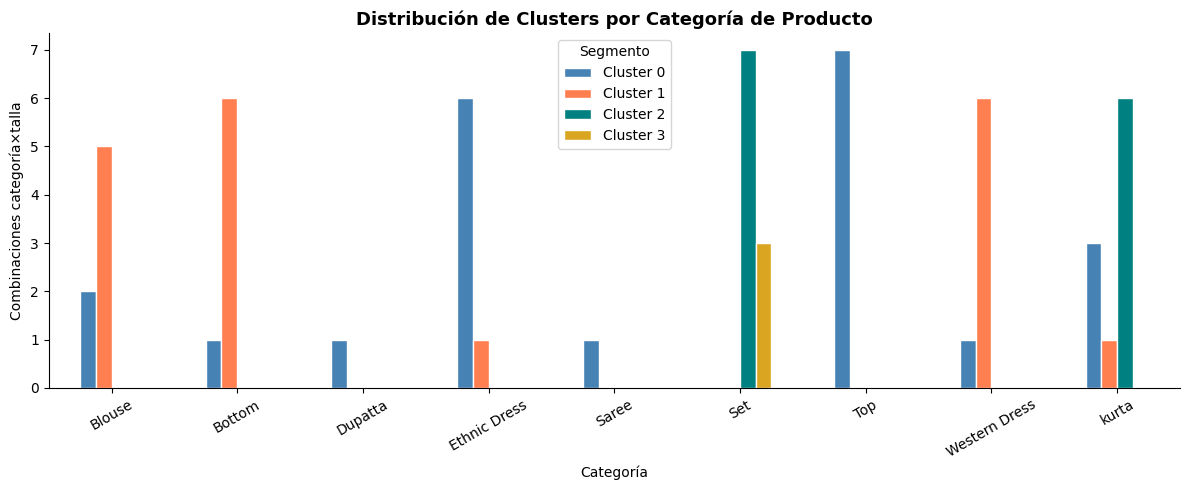

In [137]:
# ── Distribución de clusters por categoría ────────────────────────────────────
cluster_cat = cluster_df.groupby(['category', 'cluster']).size().unstack(fill_value=0)

cluster_cat.plot(kind='bar', figsize=(12, 5),
                 color=colors_clus, edgecolor='white')
plt.title('Distribución de Clusters por Categoría de Producto', fontsize=13, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Combinaciones categoría×talla')
plt.xticks(rotation=30)
plt.legend([f'Cluster {i}' for i in range(4)], title='Segmento')
plt.tight_layout()
plt.savefig('outputs/11_cluster_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Conclusiones de Negocio <a id='6'></a>

### Hallazgos principales

| # | Hallazgo | Implicación |
|---|----------|-------------|
| 1 | **Set y Kurta** representan >77% del ingreso total | Priorizar disponibilidad y campañas en estas categorías |
| 2 | **Maharashtra, Karnataka y Telangana** concentran ~43.5% del revenue | Enfocar logística y marketing en estos 3 estados |
| 3 | La tasa de cancelación global es del **~8.9%** | Implementar validación de pedidos o depósito anticipado |
| 4 | **Amazon Fulfillment** genera 69% del ingreso vs Merchant | Incentivos para que merchants migren a Amazon FBA |
| 5 | El **monto y cantidad** son los mejores predictores de cancelación | Alertas automáticas en órdenes de alto valor sin historial |
| 6 | El segmento **Cluster 1 (alto volumen/ingreso)** está dominado por Blouse, Bottom, y Western Dress en tallas M/L | Estrategia de bundling y descuento por volumen en estas combinaciones |

### Rendimiento de modelos

| Modelo | ROC-AUC | Observación |
|--------|---------|-------------|
| Logistic Regression | ~0.8204 | Baseline sólido, interpretable |
| Random Forest | ~0.8302 | Mejor desempeño, recomendado para producción |

Se recomienda Logistic Regression con umbral 0.46 cuando el costo operativo de una cancelación no detectada supera el costo de revisar falsas alarmas. Random Forest es preferible cuando se quiere minimizar interrupciones a órdenes válidas.

### Próximos pasos sugeridos
- Integrar datos de devoluciones para mejorar el modelo de cancelación
- Desarrollar dashboard interactivo en Power BI con los KPIs identificados
- Aplicar análisis de cohortes para medir retención de clientes B2B
